Libraries loaded successfully.


Saving Global cleaned.csv to Global cleaned (16).csv
Rows: 35798
Columns: 28
DATASET SHAPE
(35798, 28)

COLUMN NAMES
['record_id', 'm49_code', 'country', 'region', 'cpc_code', 'commodity', 'year', 'loss_percentage', 'loss_percentage_original', 'loss_quantity', 'activity', 'food_supply_stage', 'treatment', 'cause_of_loss', 'sample_size', 'method_data_collection', 'reference', 'url', 'notes', 'loss_quantity_numeric', 'sample_size_numeric', 'loss_pct_valid', 'has_loss_quantity', 'has_sample_size', 'has_source_url', 'has_activity', 'has_supply_stage', 'has_cause_of_loss']

DATA TYPES
record_id                     int64
m49_code                      int64
country                      object
region                       object
cpc_code                     object
commodity                    object
year                          int64
loss_percentage             float64
loss_percentage_original     object
loss_quantity                object
activity                     object
food_supply_stage

,record_id,m49_code,country,region,cpc_code,commodity,year,loss_percentage,loss_percentage_original,loss_quantity,activity,food_supply_stage,treatment,cause_of_loss,sample_size,method_data_collection,reference,url,notes,loss_quantity_numeric,sample_size_numeric,loss_pct_valid,has_loss_quantity,has_sample_size,has_source_url,has_activity,has_supply_stage,has_cause_of_loss
0,1,1,World,NaN,0111,Wheat,2022,1.0,1%,NaN,Processing,Processing,NaN,NaN,NaN,Survey,"Aintzane Esturo, (2022), Cereals Extraction Ra...",NaN,Derived product is wheat flour,NaN,NaN,True,False,False,False,True,True,False
1,2,1,World,NaN,0112,Maize (corn),2022,0.5,0.5%,NaN,Processing,Processing,NaN,NaN,NaN,Survey,"Aintzane Esturo, (2022), Cereals Extraction Ra...",NaN,Derived product is maize flour.,NaN,NaN,True,False,False,False,True,True,False
2,3,1,World,NaN,0112,Maize (corn),2022,2.0,2%,NaN,Processing,Processing,NaN,NaN,NaN,Survey,"Aintzane Esturo, (2022), Cereals Extraction Ra...",NaN,Derived product is Maize (corn) grits.,NaN,NaN,True,False,False,False,True,True,False
3,4,1,World,NaN,0112,Maize (corn),2022,2.0,2%,NaN,Processing,Processing,NaN,NaN,NaN,Survey,"Aintzane Esturo, (2022), Cereals Extraction Ra...",NaN,Derived product is Maize (corn) grits flaked.,NaN,NaN,True,False,False,False,True,True,False
4,5,1,World,NaN,0112,Maize (corn),2022,0.1,0.1%,NaN,Processing,Processing,NaN,NaN,NaN,Survey,"Aintzane Esturo, (2022), Cereals Extraction Ra...",NaN,Derived product is corn starch.,NaN,NaN,True,False,False,False,True,True,False


Duplicate rows: 0
Rows after duplicate removal: 35,798
Invalid loss percentage observations: 0


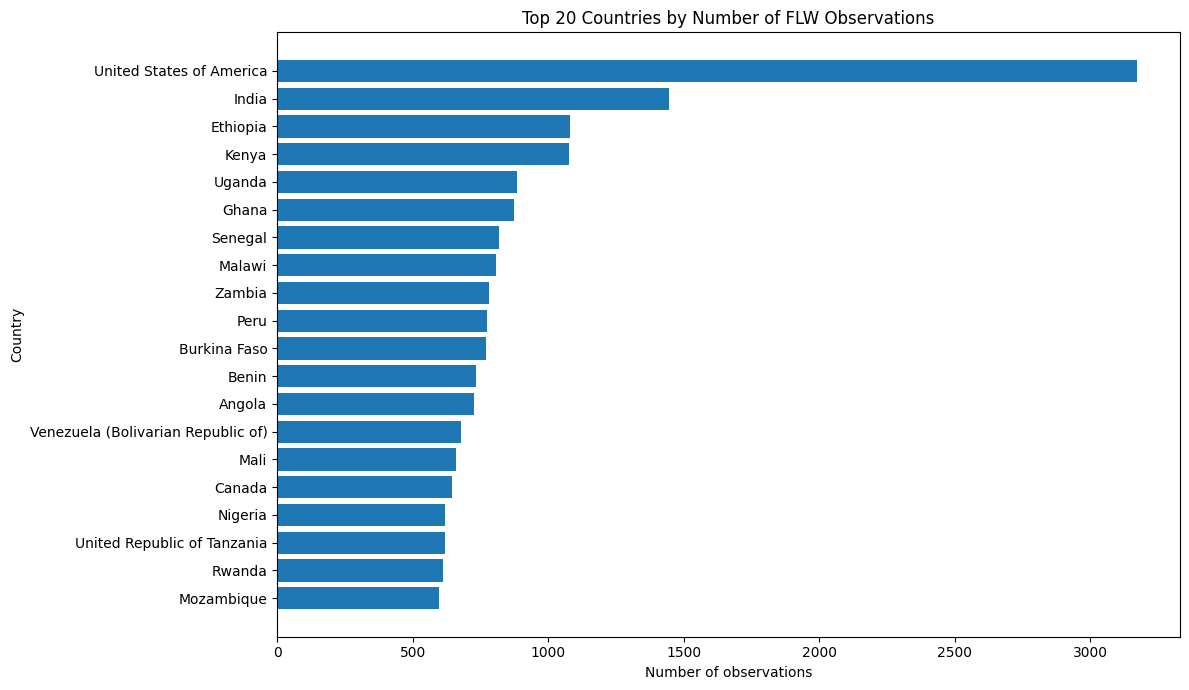

Africa observations: 17212
African countries: 34
Nigeria observations: 619


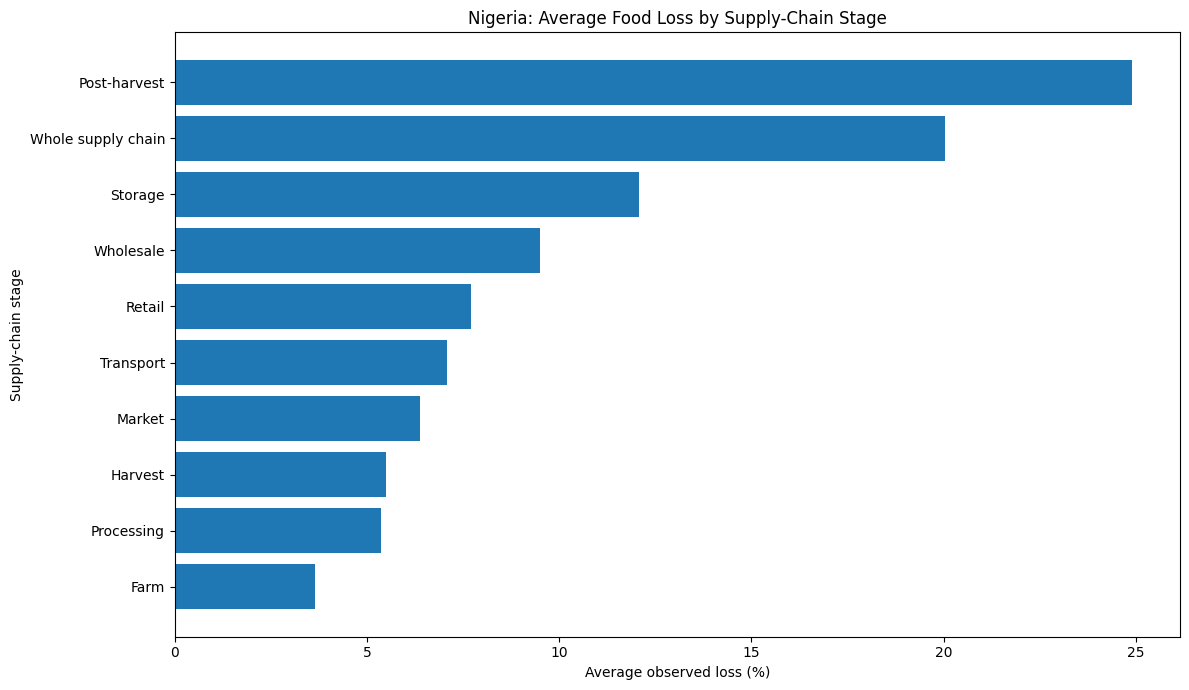

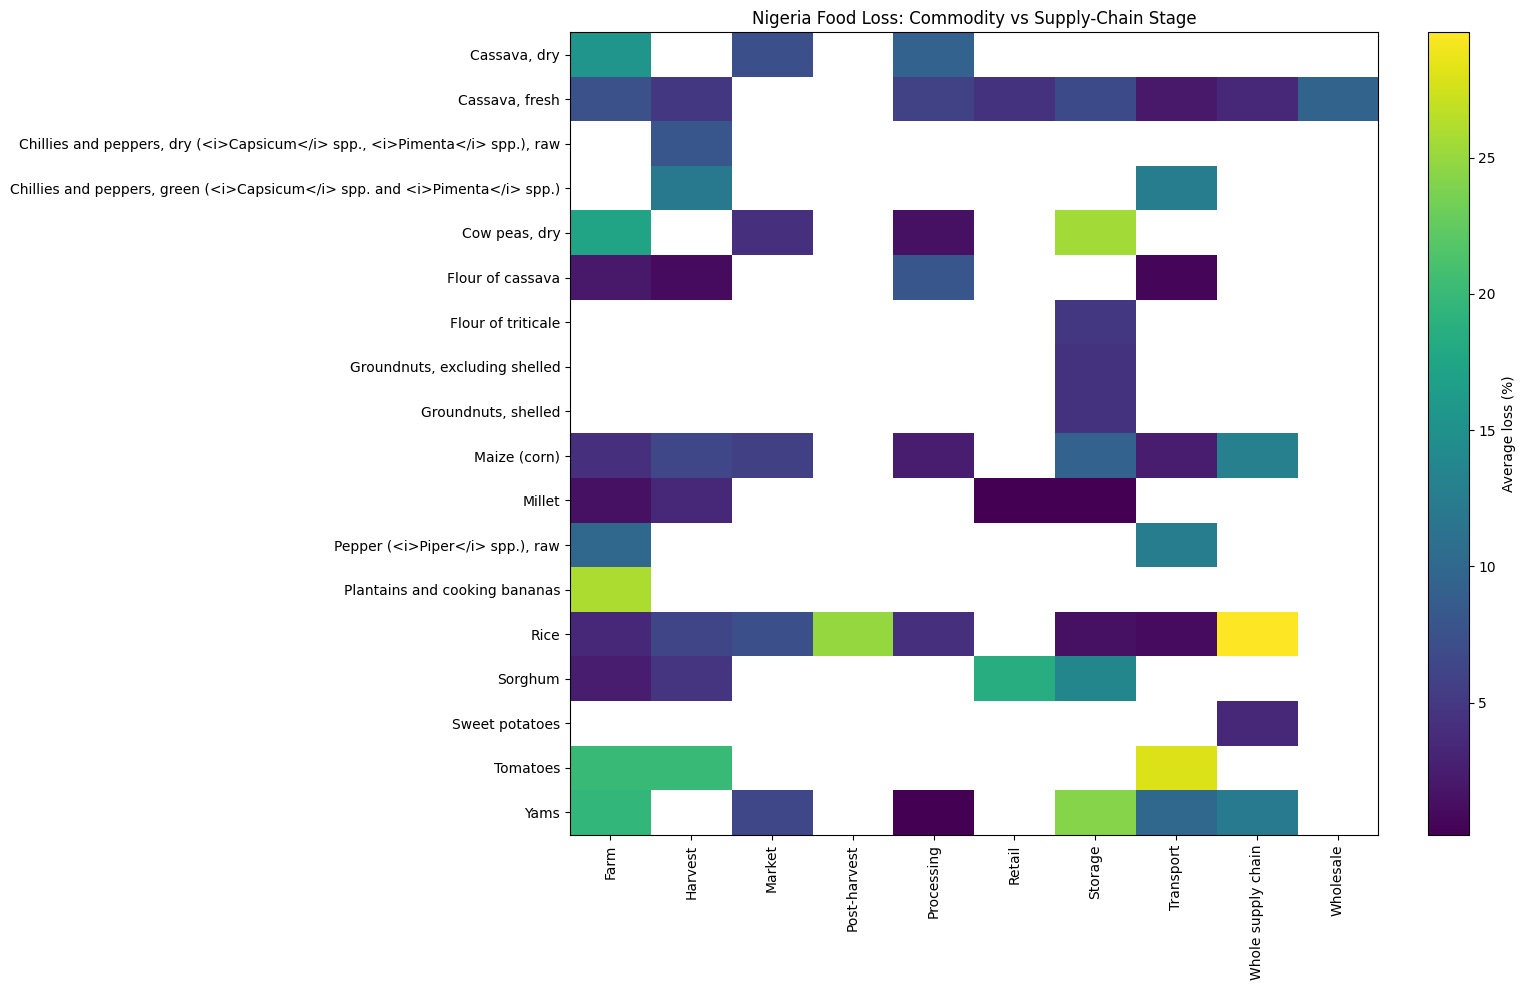

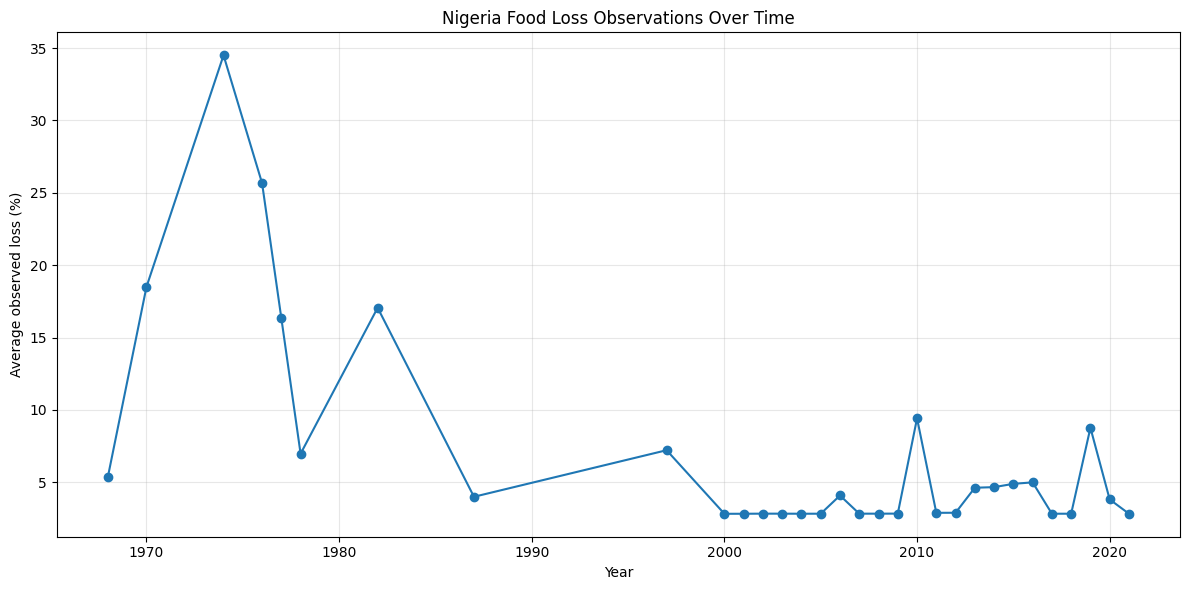

Analysis files created successfully.


In [24]:

# FOOD LOSS & WASTE ANALYSIS
# FAO Food Loss & Waste Dataset


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Statistical / analytical libraries
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

from google.colab import files

uploaded = files.upload()

df = pd.read_csv(
    "Global cleaned.csv",
    low_memory=False,
    encoding='latin1'
)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

print("DATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nFIRST 5 ROWS")
display(df.head())

quality_report = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "missing_percentage": (
        df.isna().mean().values * 100
    ).round(2),
    "unique_values": df.nunique().values
})

quality_report.sort_values(
    "missing_percentage",
    ascending=False
)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count > 0:
    df = df.drop_duplicates().copy()

print(f"Rows after duplicate removal: {len(df):,}")

df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

df["loss_percentage"] = pd.to_numeric(
    df["loss_percentage"],
    errors="coerce"
)

df["loss_quantity_numeric"] = pd.to_numeric(
    df["loss_quantity_numeric"],
    errors="coerce"
)

df["sample_size_numeric"] = pd.to_numeric(
    df["sample_size_numeric"],
    errors="coerce"
)

invalid_loss = df[
    (df["loss_percentage"] < 0) |
    (df["loss_percentage"] > 100)
]

print(
    f"Invalid loss percentage observations: "
    f"{len(invalid_loss):,}"
)

invalid_loss.head()

df = df[
    df["loss_percentage"].between(0, 100)
].copy()

summary = {
    "Observations": len(df),
    "Countries": df["country"].nunique(),
    "Commodities": df["commodity"].nunique(),
    "Years": df["year"].nunique(),
    "Supply Chain Stages": df["food_supply_stage"].nunique(),
    "Activities": df["activity"].nunique(),
    "Causes": df["cause_of_loss"].nunique()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

country_obs = (
    df.groupby("country")
      .size()
      .reset_index(name="observations")
      .sort_values("observations", ascending=False)
)


country_obs.head(20)

top20 = country_obs.head(20)

plt.figure(figsize=(12, 7))

plt.barh(
    top20["country"][::-1],
    top20["observations"][::-1]
)

plt.title("Top 20 Countries by Number of FLW Observations")
plt.xlabel("Number of observations")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


country_loss = (
    df.groupby("country")
      .agg(
          average_loss_pct=("loss_percentage", "mean"),
          median_loss_pct=("loss_percentage", "median"),
          observations=("loss_percentage", "count")
      )
      .reset_index()
)

country_loss = country_loss.sort_values(
    "average_loss_pct",
    ascending=False
)

country_loss.head(20)


africa_countries = [
    "Algeria", "Angola", "Benin", "Botswana",
    "Burkina Faso", "Burundi", "Cameroon",
    "Chad", "Côte d’Ivoire", "Egypt",
    "Ethiopia", "Ghana", "Kenya", "Libya",
    "Madagascar", "Malawi", "Mali",
    "Mauritania", "Mauritius", "Morocco",
    "Mozambique", "Namibia", "Niger",
    "Nigeria", "Rwanda", "Senegal",
    "Seychelles", "Sierra Leone",
    "Somalia", "South Africa", "Sudan",
    "Tanzania", "Togo", "Tunisia",
    "Uganda", "Zambia", "Zimbabwe"
]

africa_df = df[
    df["country"].isin(africa_countries)
].copy()

print("Africa observations:", len(africa_df))
print(
    "African countries:",
    africa_df["country"].nunique()
)


nigeria = df[
    df["country"].str.lower().eq("nigeria")
].copy()

print("Nigeria observations:", len(nigeria))

nigeria.head()




nigeria_commodities = (
    nigeria.groupby("commodity")
           .agg(
               observations=("loss_percentage", "count"),
               average_loss=("loss_percentage", "mean"),
               median_loss=("loss_percentage", "median"),
               maximum_loss=("loss_percentage", "max")
           )
           .reset_index()
           .sort_values(
               "average_loss",
               ascending=False
           )
)

nigeria_commodities


nigeria_stage = (
    nigeria.groupby("food_supply_stage")
           .agg(
               observations=("loss_percentage", "count"),
               average_loss=("loss_percentage", "mean"),
               median_loss=("loss_percentage", "median"),
               maximum_loss=("loss_percentage", "max")
           )
           .reset_index()
           .sort_values(
               "average_loss",
               ascending=False
           )
)

nigeria_stage

plt.figure(figsize=(12, 7))

stage_plot = nigeria_stage.dropna(
    subset=["food_supply_stage"]
).head(15)

plt.barh(
    stage_plot["food_supply_stage"][::-1],
    stage_plot["average_loss"][::-1]
)

plt.title(
    "Nigeria: Average Food Loss by Supply-Chain Stage"
)

plt.xlabel("Average observed loss (%)")
plt.ylabel("Supply-chain stage")

plt.tight_layout()
plt.show()


nigeria_activity = (
    nigeria.groupby("activity")
           .agg(
               observations=("loss_percentage", "count"),
               average_loss=("loss_percentage", "mean"),
               median_loss=("loss_percentage", "median")
           )
           .reset_index()
           .sort_values(
               "average_loss",
               ascending=False
           )
)

nigeria_activity.head(20)


nigeria_causes = (
    nigeria.dropna(subset=["cause_of_loss"])
           .groupby("cause_of_loss")
           .agg(
               observations=("loss_percentage", "count"),
               average_loss=("loss_percentage", "mean")
           )
           .reset_index()
           .sort_values(
               "observations",
               ascending=False
           )
)

nigeria_causes.head(20)



commodity_stage = (
    nigeria.groupby(
        ["commodity", "food_supply_stage"]
    )
    .agg(
        observations=("loss_percentage", "count"),
        average_loss=("loss_percentage", "mean"),
        median_loss=("loss_percentage", "median")
    )
    .reset_index()
)

commodity_stage.sort_values(
    "average_loss",
    ascending=False
).head(30)


heatmap_data = nigeria.pivot_table(
    index="commodity",
    columns="food_supply_stage",
    values="loss_percentage",
    aggfunc="mean"
)

plt.figure(figsize=(16, 10))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(
    label="Average loss (%)"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=90
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title(
    "Nigeria Food Loss: Commodity vs Supply-Chain Stage"
)

plt.tight_layout()
plt.show()


yearly_loss = (
    nigeria.groupby("year")
           .agg(
               average_loss=("loss_percentage", "mean"),
               median_loss=("loss_percentage", "median"),
               observations=("loss_percentage", "count")
           )
           .reset_index()
)

yearly_loss


plt.figure(figsize=(12, 6))

plt.plot(
    yearly_loss["year"],
    yearly_loss["average_loss"],
    marker="o"
)

plt.title(
    "Nigeria Food Loss Observations Over Time"
)

plt.xlabel("Year")
plt.ylabel("Average observed loss (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()




method_analysis = (
    nigeria.groupby("method_data_collection")
           .agg(
               observations=("loss_percentage", "count"),
               average_loss=("loss_percentage", "mean"),
               median_loss=("loss_percentage", "median")
           )
           .reset_index()
           .sort_values(
               "observations",
               ascending=False
           )
)

method_analysis


sample_analysis = nigeria[
    nigeria["sample_size_numeric"].notna()
].copy()

sample_analysis[
    [
        "commodity",
        "food_supply_stage",
        "loss_percentage",
        "sample_size_numeric",
        "method_data_collection"
    ]
].head(20)


correlation_data = nigeria[
    ["loss_percentage", "sample_size_numeric"]
].dropna()

correlation = correlation_data.corr()

correlation


hotspots = (
    nigeria.groupby(
        ["commodity", "food_supply_stage"]
    )
    .agg(
        observations=("loss_percentage", "count"),
        average_loss=("loss_percentage", "mean"),
        median_loss=("loss_percentage", "median"),
        max_loss=("loss_percentage", "max")
    )
    .reset_index()
)

hotspots = hotspots[
    hotspots["observations"] >= 3
].copy()

hotspots["hotspot_score"] = (
    hotspots["average_loss"] *
    np.log1p(hotspots["observations"])
)

hotspots = hotspots.sort_values(
    "hotspot_score",
    ascending=False
)

hotspots.head(20)



africa_summary = (
    africa_df.groupby("country")
             .agg(
                 observations=("loss_percentage", "count"),
                 average_loss=("loss_percentage", "mean"),
                 median_loss=("loss_percentage", "median")
             )
             .reset_index()
)

africa_summary = africa_summary[
    africa_summary["observations"] >= 10
].sort_values(
    "average_loss",
    ascending=False
)

africa_summary.head(20)



output_folder = Path("food_waste_analysis_outputs")

output_folder.mkdir(
    exist_ok=True
)

country_loss.to_csv(
    output_folder / "country_loss_summary.csv",
    index=False
)

nigeria_commodities.to_csv(
    output_folder / "nigeria_commodity_analysis.csv",
    index=False
)

nigeria_stage.to_csv(
    output_folder / "nigeria_stage_analysis.csv",
    index=False
)

nigeria_activity.to_csv(
    output_folder / "nigeria_activity_analysis.csv",
    index=False
)

nigeria_causes.to_csv(
    output_folder / "nigeria_cause_analysis.csv",
    index=False
)

hotspots.to_csv(
    output_folder / "nigeria_food_loss_hotspots.csv",
    index=False
)

print("Analysis files created successfully.")

In [25]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=nigeria_commodities)

https://docs.google.com/spreadsheets/d/1TSMwPgE1gdmDwkzxg7YwgwEHtJsUmUoSCnX5j58I1IY/edit#gid=0


In [26]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=nigeria_commodities)

https://docs.google.com/spreadsheets/d/1Q1LFNXIsax6jRrxd_Ornw8SzXhuddbtKjspU4CFtJfY/edit#gid=0
